In [50]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [51]:
df = pd.read_csv(r"D:\GitHubRepos\is6400-business-data-analytics\data\The_boss.csv")
df.head(10)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399.000000,5,701,2010,4,1,2,3.5,186005,6,0,0,1,0,12,12
1,44731507,16621,1018.000000,1,407,2011,4,0,5,3.0,192000,6,2,0,1,0,1,8
2,45774419,8467,1599.333333,3,425,2006,3,0,5,1.3,200000,4,3,1,1,1,1,2
3,45769185,3607,862.000000,2,409,2011,4,1,2,2.5,168966,4,0,0,1,0,14,0
4,45809263,11726,446.000000,3,425,2014,3,1,5,1.3,91901,4,0,1,1,0,12,4
5,45802912,39493,891.000000,4,733,2016,4,1,1,2.0,160931,4,0,1,1,0,14,4
6,45656768,1803,761.000000,7,643,2010,3,1,2,1.8,258909,4,0,1,1,0,14,12
7,45816158,549,751.000000,4,748,2013,9,1,5,2.4,216118,4,0,1,1,0,7,12
8,45641395,1098,394.000000,7,268,2014,9,1,2,2.5,398069,4,0,1,1,0,1,12
9,45756839,26657,1624.000000,5,694,2007,4,1,5,3.5,128500,6,0,0,1,0,12,12


In [52]:
# 数据预处理函数
def preprocess_data(df):
    # 处理缺失值
    df['Levy'] = df['Levy'].fillna(df['Levy'].median())
    # 异常值处理（价格过滤）
    price_q1 = df['Price'].quantile(0.05)
    price_q3 = df['Price'].quantile(0.95)
    df = df[(df['Price'] > price_q1) & (df['Price'] < price_q3)]
    # 对数变换长尾分布特征
    df['Mileage_log'] = np.log1p(df['Mileage'])
    df['Engine_vol_log'] = np.log1p(df['Engine volume'])
    df = df[df['Price'] < 1e6]
    # 时间敏感特征
    df['Depreciation'] = (2024 - df['Prod. year']) * df['Mileage'] / 1e5
    # 品牌溢价编码
    brand_prestige = {'LEXUS': 5, 'MERCEDES-BENZ': 4, 'BMW': 4, 'TOYOTA': 3}
    df['Brand_Score'] = df['Manufacturer'].map(brand_prestige).fillna(2)
    # 删除冗余特征
    df = df.drop(['ID', 'Doors', 'Color', 'Cylinders', 'Drive wheels'], axis=1, errors='ignore')
    
    return df

In [53]:
df = preprocess_data(df)

C:\Users\wjw20\AppData\Local\Temp\ipykernel_4068\2871126385.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Mileage_log'] = np.log1p(df['Mileage'])
C:\Users\wjw20\AppData\Local\Temp\ipykernel_4068\2871126385.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Engine_vol_log'] = np.log1p(df['Engine volume'])


In [54]:
# 定义特征和目标变量
X = df.drop(['Price', 'Mileage', 'Engine volume'], axis=1)  # 移除原始数值特征
y = np.log1p(df['Price'])  # 对数变换目标变量

In [55]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
# 特征预处理管道
numeric_features = ['Levy', 'Prod. year', 'Airbags']
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])
categorical_features = ['Manufacturer', 'Category', 'Fuel type', 'Gear box type']
categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', max_categories=50))
])

In [57]:
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.layers import LeakyReLU, PReLU
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.layers import Input, Add

# 构建MLP模型
# def build_mlp(input_dim):
#     init = HeNormal(seed=42)
#     reg = l1_l2(l1=1e-5, l2=1e-4)
    
#     # 使用函数式API构建残差连接
#     input_tensor = Input(shape=(input_dim,))
    
#     # 输入分支
#     x = Dense(512, kernel_initializer=init, kernel_regularizer=reg)(input_tensor)
#     x = BatchNormalization()(x)
#     x = LeakyReLU(alpha=0.1)(x)
#     x = Dropout(0.3)(x)
    
#     # 残差块
#     residual = x
#     x = Dense(256, kernel_regularizer=reg)(x)
#     x = BatchNormalization()(x)
#     x = PReLU()(x)
#     x = Dropout(0.2)(x)
#     x = Dense(512)(x)
#     x = Add()([residual, x])  # 正确使用Add层
    
#     # 后续层保持原样
#     x = Dense(64, activation='selu', kernel_initializer='lecun_normal')(x)
#     outputs = Dense(1, activation='linear')(x)
    
#     model = tf.keras.Model(inputs=input_tensor, outputs=outputs)
    
#     # 混合损失函数
#     def hybrid_loss(y_true, y_pred):
#         mae = tf.keras.losses.MAE(y_true, y_pred)
#         mse = tf.keras.losses.MSE(y_true, y_pred)
#         return 0.7*mae + 0.3*mse
    
#     # 自定义R²指标
#     class R2Score(tf.keras.metrics.Metric):
#         def __init__(self, name='r2', **kwargs):
#             super().__init__(name=name, **kwargs)
#             self.ss_res = self.add_weight(name='ss_res', initializer='zeros')
#             self.ss_tot = self.add_weight(name='ss_tot', initializer='zeros')

#         def update_state(self, y_true, y_pred, sample_weight=None):
#             y_true = tf.cast(y_true, tf.float32)
#             y_pred = tf.cast(y_pred, tf.float32)
#             ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
#             ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
#             self.ss_res.assign_add(ss_res)
#             self.ss_tot.assign_add(ss_tot)

#         def result(self):
#             return 1 - self.ss_res / (self.ss_tot + tf.keras.backend.epsilon())

#     # 模型编译
#     model.compile(
#         optimizer=Nadam(learning_rate=0.001, clipvalue=0.5),
#         loss=hybrid_loss,
#         metrics=[R2Score(), 'mae']
#     )
    
#     return model

def build_mlp(input_dim):
    init = tf.keras.initializers.HeNormal(seed=42)
    reg = tf.keras.regularizers.l1_l2(l1=1e-5, l2=1e-4)
    
    # 输入层
    input_tensor = tf.keras.layers.Input(shape=(input_dim,))
    
    # 初始特征提取
    x = tf.keras.layers.Dense(512, kernel_initializer=init, kernel_regularizer=reg)(input_tensor)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    # 残差块
    residual = x
    x = tf.keras.layers.Dense(256, kernel_regularizer=reg)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.PReLU()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(512)(x)
    x = tf.keras.layers.Add()([residual, x])
    
    # 特征注意力机制
    def feature_attention(inputs):
        """ 结构化数据特征注意力 """
        # 生成注意力分数 [batch_size, features]
        attn_scores = tf.keras.layers.Dense(
            inputs.shape[-1],  # 保持与特征维度一致
            activation='sigmoid',  # 使用sigmoid替代softmax允许特征多激活
            kernel_initializer='glorot_normal'
        )(inputs)
        
        # 应用注意力加权 [batch_size, features]
        weighted_features = tf.keras.layers.Multiply()([inputs, attn_scores])
        
        # 残差连接
        return tf.keras.layers.Add()([inputs, weighted_features])
    
    x = feature_attention(x)

    # 混合损失函数
    def hybrid_loss(y_true, y_pred):
        mae = tf.keras.losses.MAE(y_true, y_pred)
        mse = tf.keras.losses.MSE(y_true, y_pred)
        return 0.7*mae + 0.3*mse
    
    # 后续处理
    x = tf.keras.layers.Dense(64, activation='selu', kernel_initializer='lecun_normal')(x)
    outputs = tf.keras.layers.Dense(1, activation='linear')(x)
    
    # 构建模型
    model = tf.keras.Model(inputs=input_tensor, outputs=outputs)

    # 自定义R²指标
    class R2Score(tf.keras.metrics.Metric):
        def __init__(self, name='r2', **kwargs):
            super().__init__(name=name, **kwargs)
            self.ss_res = self.add_weight(name='ss_res', initializer='zeros')
            self.ss_tot = self.add_weight(name='ss_tot', initializer='zeros')

        def update_state(self, y_true, y_pred, sample_weight=None):
            y_true = tf.cast(y_true, tf.float32)
            y_pred = tf.cast(y_pred, tf.float32)
            ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
            ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
            self.ss_res.assign_add(ss_res)
            self.ss_tot.assign_add(ss_tot)

        def result(self):
            return 1 - self.ss_res / (self.ss_tot + tf.keras.backend.epsilon())
    
    # 编译配置（保持原有损失函数和指标）
    model.compile(
        optimizer=tf.keras.optimizers.Nadam(learning_rate=0.001, clipvalue=0.5),
        loss=hybrid_loss,
        metrics=[R2Score(), 'mae']
    )
    
    return model

In [58]:
# 数据预处理
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', max_categories=50), categorical_features)
])

In [59]:
# 数据预处理
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [60]:
# 获取预处理后的特征维度
input_dim = X_train_processed.shape[1]

In [61]:
# 初始化模型
mlp = build_mlp(input_dim)

c:\Users\wjw20\miniconda3\envs\IS6400\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [62]:
# 添加学习率调度函数（在调用 fit() 之前）
def lr_schedule(epoch):
    """ 动态调整学习率 """
    base_lr = 0.001
    decay_rate = 0.9
    return base_lr * (decay_rate ** (epoch // 10))  # 每10个epoch衰减一次

In [63]:
# 训练模型
history = mlp.fit(
    X_train_processed.astype('float32'), 
    y_train.values.astype('float32'),
    validation_split=0.2,
    epochs=120,
    batch_size=128,
    callbacks=[
        LearningRateScheduler(lr_schedule),
        tf.keras.callbacks.TensorBoard(log_dir='./logs'),
        tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True)
    ],
)

Epoch 1/120
61/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.3463 - mae: 2.1096 - r2: -1103.8545

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.1133 - mae: 2.0433 - r2: -1051.8682 - val_loss: 4.2707 - val_mae: 2.5573 - val_r2: -681.8141 - learning_rate: 0.0010
Epoch 2/120
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1577 - mae: 0.8141 - r2: -197.4768

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.1560 - mae: 0.8128 - r2: -197.3929 - val_loss: 2.0015 - val_mae: 1.4341 - val_r2: -320.1370 - learning_rate: 0.0010
Epoch 3/120
60/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0324 - mae: 0.7224 - r2: -189.7998

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0318 - mae: 0.7219 - r2: -189.8789 - val_loss: 1.3457 - val_mae: 1.0021 - val_r2: -238.1204 - learning_rate: 0.0010
Epoch 4/120
59/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9767 - mae: 0.6805 - r2: -193.2413

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9773 - mae: 0.6809 - r2: -192.9791 - val_loss: 1.1101 - val_mae: 0.8077 - val_r2: -228.7216 - learning_rate: 0.0010
Epoch 5/120
62/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9386 - mae: 0.6540 - r2: -193.3430

...

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5728 - mae: 0.4688 - r2: -211.6378 - val_loss: 0.6549 - val_mae: 0.5227 - val_r2: -204.8398 - learning_rate: 3.8742e-04
Epoch 100/120
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5834 - mae: 0.4755 - r2: -205.8611 - val_loss: 0.6634 - val_mae: 0.5309 - val_r2: -217.2335 - learning_rate: 3.8742e-04
Epoch 101/120
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5944 - mae: 0.4836 - r2: -206.2998 - val_loss: 0.6654 - val_mae: 0.5351 - val_r2: -217.8549 - learning_rate: 3.4868e-04
Epoch 102/120
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5746 - mae: 0.4722 - r2: -208.9034 - val_loss: 0.6599 - val_mae: 0.5310 - val_r2: -216.8250 - learning_rate: 3.4868e-04
Epoch 103/120
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5783 - mae: 0.4721 - r2: -211.1116

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5784 - mae: 0.4722 - r2: -211.0539 - val_loss: 0.6518 - val_mae: 0.5213 - val_r2: -204.4612 - learning_rate: 3.4868e-04
Epoch 104/120
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5744 - mae: 0.4678 - r2: -205.6133 - val_loss: 0.6570 - val_mae: 0.5259 - val_r2: -216.5462 - learning_rate: 3.4868e-04
Epoch 105/120
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5912 - mae: 0.4853 - r2: -209.2160 - val_loss: 0.6554 - val_mae: 0.5254 - val_r2: -211.6214 - learning_rate: 3.4868e-04
Epoch 106/120
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5803 - mae: 0.4733 - r2: -210.1583 - val_loss: 0.6587 - val_mae: 0.5305 - val_r2: -203.9649 - learning_rate: 3.4868e-04
Epoch 107/120
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5761 - mae: 0.4734 - r2: -208.2390 - val_loss: 0.6553 - val_mae: 0.5264 - val_r2: -215.5189 - learning_rate: 3.4868e-04
Epoch 108/120
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5887 - mae: 0.4812 - r2: -204.8936 -

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5757 - mae: 0.4733 - r2: -206.1363 - val_loss: 0.6488 - val_mae: 0.5221 - val_r2: -211.5747 - learning_rate: 3.1381e-04
Epoch 114/120
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5700 - mae: 0.4677 - r2: -208.4312 - val_loss: 0.6525 - val_mae: 0.5248 - val_r2: -220.9482 - learning_rate: 3.1381e-04
Epoch 115/120
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5719 - mae: 0.4689 - r2: -211.6059 - val_loss: 0.6589 - val_mae: 0.5291 - val_r2: -206.1204 - learning_rate: 3.1381e-04
Epoch 116/120
62/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5703 - mae: 0.4699 - r2: -204.9077

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5705 - mae: 0.4700 - r2: -205.0311 - val_loss: 0.6468 - val_mae: 0.5228 - val_r2: -207.3488 - learning_rate: 3.1381e-04
Epoch 117/120
63/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5720 - mae: 0.4697 - r2: -207.4621

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5722 - mae: 0.4699 - r2: -207.3968 - val_loss: 0.6451 - val_mae: 0.5198 - val_r2: -204.0199 - learning_rate: 3.1381e-04
Epoch 118/120
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5483 - mae: 0.4534 - r2: -208.2385 - val_loss: 0.6488 - val_mae: 0.5266 - val_r2: -213.4345 - learning_rate: 3.1381e-04
Epoch 119/120
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5815 - mae: 0.4791 - r2: -209.6158 - val_loss: 0.6510 - val_mae: 0.5265 - val_r2: -212.0958 - learning_rate: 3.1381e-04
Epoch 120/120
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5624 - mae: 0.4650 - r2: -210.5220 - val_loss: 0.6493 - val_mae: 0.5267 - val_r2: -211.1001 - learning_rate: 3.1381e-04


In [64]:
# 修正MAE计算方式（正确方法）
def evaluate_model(model, X, y):
    y_pred = model.predict(X).flatten()
    y_true = y.values.flatten()
    
    # 先计算差异再还原
    abs_error = np.abs(np.expm1(y_pred) - np.expm1(y_true))
    
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²': r2_score(y_true, y_pred),
        'MAE': np.median(abs_error)  # 使用中位数抗异常值
    }

In [65]:
print("\nTrain Metrics:", evaluate_model(mlp, X_train_processed, y_train))
print("Test Metrics:", evaluate_model(mlp, X_test_processed, y_test))

323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Train Metrics: {'RMSE': 0.7484785911894757, 'R²': 0.6321099594330948, 'MAE': 2245.840820312502}
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test Metrics: {'RMSE': 0.849848811533619, 'R²': 0.5245536080464652, 'MAE': 2707.5804443359343}


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


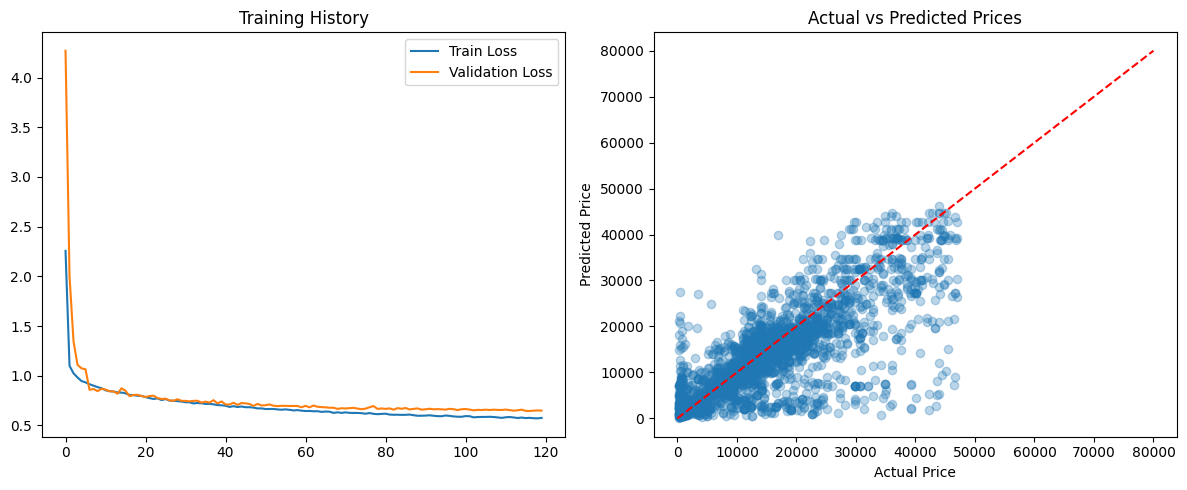

In [66]:
# 训练过程可视化
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training History')
plt.legend()

# 预测结果可视化
plt.subplot(1, 2, 2)
plt.scatter(np.expm1(y_test), np.expm1(mlp.predict(X_test_processed)), alpha=0.3)
plt.plot([0, 80000], [0, 80000], '--r')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.tight_layout()
plt.show()